# Northbridge Policy Assistant — RAG Pipeline


In [1]:
!pip install langchain-openai langgraph pypdf


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [9]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env file automatically

from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path("../.env"))  # go up one level from notebooks/ to root


True

In [ ]:
import os
import json
import hashlib
import operator
import numpy as np
import pandas as pd

from pathlib import Path
from pypdf import PdfReader
from typing import TypedDict, List, Annotated

!pip install python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Load Data

In [11]:
DATA_DIR      = Path("../data")
DOCUMENTS_DIR = Path("../documents")

fundraising = pd.read_csv(DATA_DIR / "northbridge_fundraising_history.csv")
partners    = pd.read_csv(DATA_DIR / "northbridge_partner_intake_reports.csv")
volunteers  = pd.read_csv(DATA_DIR / "northbridge_volunteer_roster.csv")

print("Fundraising rows:", len(fundraising))
print("Partners rows:   ", len(partners))
print("Volunteers rows: ", len(volunteers))

Fundraising rows: 60
Partners rows:    14
Volunteers rows:  20


In [12]:
# ---------- Document loaders ----------
def load_csv_as_text(df: pd.DataFrame, name: str) -> str:
    return f"[{name}]\n" + df.to_string(index=False)

def load_pdf_as_text(path: Path) -> str:
    reader = PdfReader(str(path))
    pages  = []
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        if text.strip():
            pages.append(f"[Page {i+1}]\n{text}")
    return "\n\n".join(pages)

def load_all_documents() -> list[dict]:
    docs = []
    for name, df in [("fundraising_history", fundraising),
                     ("partner_intake_reports", partners),
                     ("volunteer_roster", volunteers)]:
        docs.append({"source": name, "text": load_csv_as_text(df, name)})
        print(f"  Loaded CSV: {name}")
    for pdf_path in DOCUMENTS_DIR.rglob("*.pdf"):
        docs.append({"source": pdf_path.name, "text": load_pdf_as_text(pdf_path)})
        print(f"  Loaded PDF: {pdf_path.name}")
    print(f"\n✓ {len(docs)} documents loaded.")
    return docs

DOCS = load_all_documents()

  Loaded CSV: fundraising_history
  Loaded CSV: partner_intake_reports
  Loaded CSV: volunteer_roster
  Loaded PDF: Northbridge_Brand_Guidelines.pdf
  Loaded PDF: Northbridge_Advocacy_Inquiry_Memo.pdf
  Loaded PDF: Northbridge_Volunteer_Onboarding_and_Coordination_Manual.pdf
  Loaded PDF: Northbridge_Advocacy_FAQ.pdf
  Loaded PDF: Northbridge_Evaluation.pdf
  Loaded PDF: Northbridge_Strategic_Plan.pdf
  Loaded PDF: Northbridge_Policy_Brief_Food.pdf
  Loaded PDF: Northbridge_Food_Access_Internal_FAQ.pdf
  Loaded PDF: Northbridge_Policy_Brief_Volunteers.pdf
  Loaded PDF: Northbridge_Content_Standards.pdf

✓ 13 documents loaded.


## Chunk & Index

In [13]:
CHUNK_SIZE    = 500
CHUNK_OVERLAP = 50

def chunk_text(text: str, source: str) -> list[dict]:
    words, chunks, start = text.split(), [], 0
    while start < len(words):
        end  = min(start + CHUNK_SIZE, len(words))
        body = " ".join(words[start:end])
        chunks.append({"chunk_id": hashlib.md5(body.encode()).hexdigest()[:8],
                       "source": source, "text": body})
        if end == len(words): break
        start += CHUNK_SIZE - CHUNK_OVERLAP
    return chunks

ALL_CHUNKS = [c for doc in DOCS for c in chunk_text(doc["text"], doc["source"])]
print(f"✓ {len(ALL_CHUNKS)} chunks created.")

✓ 26 chunks created.


In [14]:
# ---------- BM25 Retriever ----------
class BM25Retriever:
    def __init__(self, chunks, k1=1.5, b=0.75):
        self.chunks = chunks
        self.k1, self.b = k1, b
        self._build_index()

    def _tok(self, t): return t.lower().split()

    def _build_index(self):
        self.corpus = [self._tok(c["text"]) for c in self.chunks]
        N     = len(self.corpus)
        avgdl = sum(len(d) for d in self.corpus) / max(N, 1)
        df = {}
        for doc in self.corpus:
            for t in set(doc): df[t] = df.get(t, 0) + 1
        self.idf   = {t: np.log((N - f + 0.5) / (f + 0.5) + 1) for t, f in df.items()}
        self.avgdl = avgdl

    def retrieve(self, query: str, top_k=5) -> list[dict]:
        q_terms = self._tok(query)
        scores  = []
        for i, doc in enumerate(self.corpus):
            dl   = len(doc)
            freq = {}
            for t in doc: freq[t] = freq.get(t, 0) + 1
            score = 0.0
            for term in q_terms:
                if term not in self.idf: continue
                tf = freq.get(term, 0)
                score += self.idf[term] * (tf * (self.k1 + 1)) / (tf + self.k1 * (1 - self.b + self.b * dl / self.avgdl))
            scores.append((i, score))
        scores.sort(key=lambda x: x[1], reverse=True)
        return [self.chunks[i] for i, _ in scores[:top_k]]

RETRIEVER = BM25Retriever(ALL_CHUNKS)
print("✓ BM25 index ready.")

✓ BM25 index ready.


## LangChain Tool & Model

In [15]:
# ---------- LangChain tool wrapper ----------
from langchain_core.tools import tool

@tool
def search_documents(query: str) -> str:
    """
    Search Northbridge's internal documents (CSVs and PDFs).
    Input: query (the question or topic to look up).
    Output: relevant passages from Northbridge documents.
    Always call this before answering any factual question.
    """
    chunks = RETRIEVER.retrieve(query, top_k=5)
    parts  = [f"[Source {i+1}: {c['source']}]\n{c['text']}" for i, c in enumerate(chunks)]
    return "\n\n---\n\n".join(parts)

TOOLS = [search_documents]

# ---------- LangChain model ----------
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage, ToolMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(TOOLS)

## System Message

In [16]:
# ---------- System Message ----------
SYSTEM_PROMPT = """You are the Northbridge Policy Assistant — a knowledgeable,
professional assistant for the Northbridge nonprofit organization.

You have access to Northbridge's internal documents including fundraising history,
partner intake reports, volunteer roster, brand guidelines, support manuals,
and advocacy memos.

Tool policy:
- ALWAYS call search_documents before answering any factual question.
- After searching, cite the source document in your answer.
- NEVER invent facts. Only state what the documents support.
- If the documents don't contain enough information, say so clearly.
"""

## LangGraph

In [17]:
# ---------- LangGraph ----------
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

def assistant_node(state: State):
    ai_msg = llm.invoke(state["messages"])
    return {"messages": [ai_msg]}

def route(state: State) -> str:
    last = state["messages"][-1]
    return "tools" if getattr(last, "tool_calls", None) else "end"

def tools_node(state: State):
    last: AIMessage = state["messages"][-1]
    tool_messages: List[ToolMessage] = []

    for tc in last.tool_calls or []:
        if tc["name"] == "search_documents":
            result = search_documents.invoke(tc["args"])
            tool_messages.append(
                ToolMessage(
                    name="search_documents",
                    content=result,
                    tool_call_id=tc["id"],
                )
            )
    return {"messages": tool_messages}

# --------------- Build Graph --------------
graph = StateGraph(State)
graph.add_node("assistant", assistant_node)
graph.add_node("tools",     tools_node)

graph.add_edge(START, "assistant")
graph.add_conditional_edges("assistant", route, {"tools": "tools", "end": END})
graph.add_edge("tools", "assistant")

app = graph.compile()

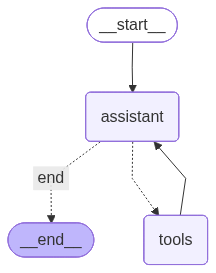

In [18]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Interactive Chat

In [19]:
def main():
    print("Northbridge Policy Assistant")
    print("Type 'exit' to end the chat.\n")

    state: State = {
        "messages": [SystemMessage(content=SYSTEM_PROMPT)]
    }

    # Kick off with a greeting
    state = app.invoke({
        "messages": state["messages"] + [HumanMessage(content="Hello! What can you help me with?")]
    })
    print("Bot:", state["messages"][-1].content, "\n")

    while True:
        user_input = input("You: ")
        if user_input.lower().strip() == "exit":
            return state

        state = app.invoke({
            "messages": state["messages"] + [HumanMessage(content=user_input)]
        })
        print("Bot:", state["messages"][-1].content)

## Print Transcript

In [ ]:
def print_transcript(messages):
    for m in messages:
        if m.__class__.__name__ == "HumanMessage":
            print("🧑 USER")
            print(m.content)
            print()

        elif m.__class__.__name__ == "AIMessage":
            if m.content:
                print("🤖 ASSISTANT")
                print(m.content)
                print()
            if getattr(m, "tool_calls", None):
                for tc in m.tool_calls:
                    print(f"🔧 TOOL CALL: {tc['name']}")
                    print(json.dumps(tc["args"], indent=2))
                    print()

        elif m.__class__.__name__ == "ToolMessage":
            print(f"📦 TOOL OUTPUT: {m.name}")
            print(m.content[:300], "...")
            print()

In [ ]:
print_transcript(final_state["messages"])